In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
# Load dataset
df = pd.read_csv('/content/Fraud_Analysis_Dataset.csv')



In [5]:
# Show first 5 rows
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [6]:
# Information about dataset (data types, nulls)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [7]:
# Check missing values
df.isnull().sum()


,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [8]:
# Statistical summary
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


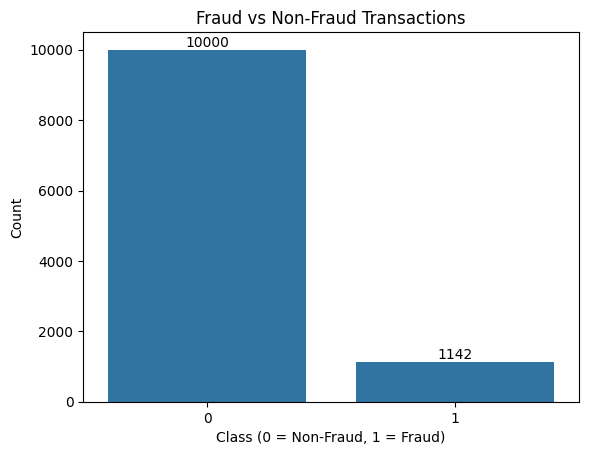

In [35]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")

# Add numbers on bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2, p.get_height()),
                       ha='center', va='bottom')

plt.show()

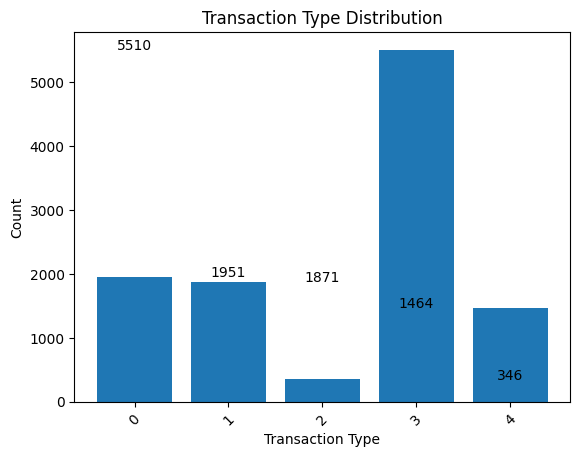

In [39]:
# Count transaction types
type_counts = df['type'].value_counts()

# Sort values
type_counts = type_counts.sort_values(ascending=False)

# Plot
plt.figure()
plt.bar(type_counts.index, type_counts.values)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

# Rotate labels
plt.xticks(rotation=45)

# Add values on top
for i, v in enumerate(type_counts.values):
    plt.text(i, v, str(v), ha='center')

plt.show()

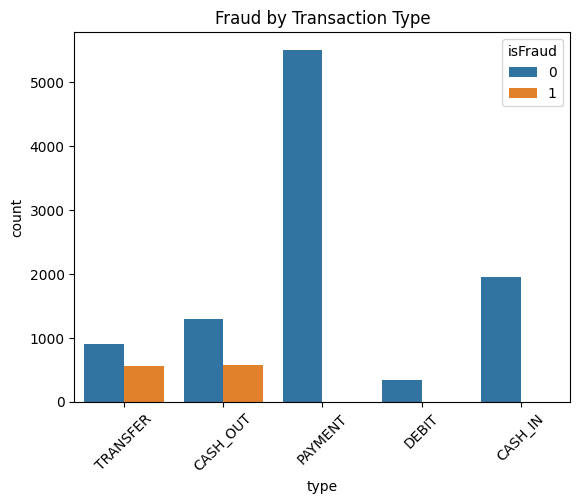

In [14]:
# Compare fraud across transaction types
sns.countplot(x='type', hue='isFraud', data=df)
plt.xticks(rotation=45)

# Shows fraud mainly in transfer/cash-out
plt.title("Fraud by Transaction Type")
plt.show()

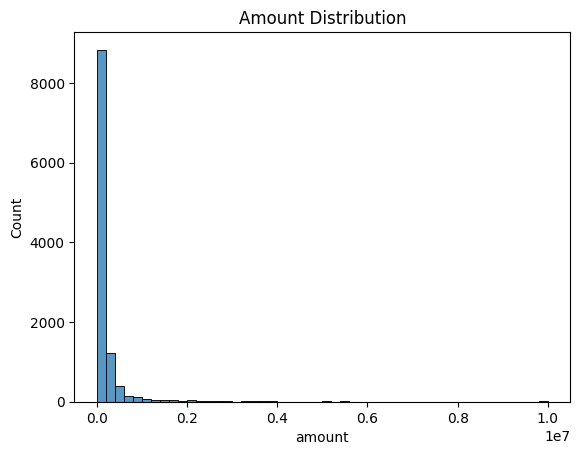

In [15]:
# Distribution of transaction amounts
sns.histplot(df['amount'], bins=50)

# Helps understand spread of values
plt.title("Amount Distribution")
plt.show()

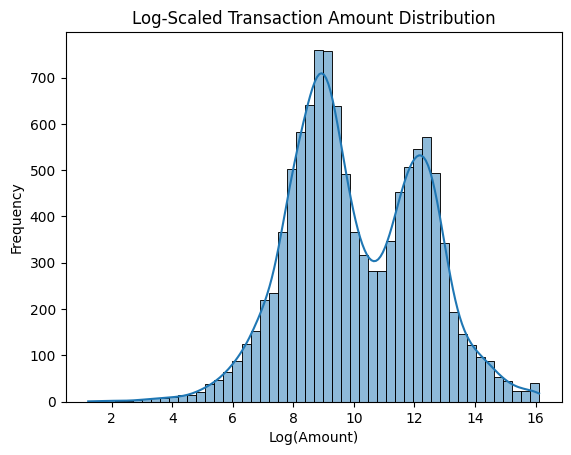

In [44]:
# Log transformation for better visualization
sns.histplot(np.log1p(df['amount']), bins=50, kde=True)

plt.title("Log-Scaled Transaction Amount Distribution")
plt.xlabel("Log(Amount)")
plt.ylabel("Frequency")

plt.show()

In [17]:
# Drop unnecessary columns (IDs not useful)
df = df.drop(['nameOrig', 'nameDest'], axis=1)

In [18]:
# Convert categorical 'type' to numeric
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [19]:
# Create new feature (balance difference)
df['balanceDiff'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# This helps detect suspicious transactions

In [20]:
# X = input features, y = target variable
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [23]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Simple baseline model
lr = LogisticRegression(max_iter=1000)  # max_iter ensures convergence
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [26]:
# Tree-based model (rule-based learning)
dt = DecisionTreeClassifier(max_depth=5)  # control complexity
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [27]:
# Distance-based model
knn = KNeighborsClassifier(n_neighbors=5)  # number of neighbors
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [29]:
# Using Random Forest (usually best)
rf = RandomForestClassifier(n_estimators=100, random_state=42) # Initialize the model
rf.fit(X_train, y_train) # Train the model
y_pred = rf.predict(X_test)

In [46]:
# Compare models
print("Logistic Regression:\n", classification_report(y_test, lr.predict(X_test)))
print("Decision Tree:\n", classification_report(y_test, dt.predict(X_test)))
print("KNN:\n", classification_report(y_test, knn.predict(X_test)))
print("Random Forest:\n", classification_report(y_test, rf.predict(X_test)))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1999
           1       1.00      0.90      0.95       230

    accuracy                           0.99      2229
   macro avg       0.99      0.95      0.97      2229
weighted avg       0.99      0.99      0.99      2229

Decision Tree:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1999
           1       1.00      0.94      0.97       230

    accuracy                           0.99      2229
   macro avg       0.99      0.97      0.98      2229
weighted avg       0.99      0.99      0.99      2229

KNN:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1999
           1       0.92      0.87      0.89       230

    accuracy                           0.98      2229
   macro avg       0.95      0.93      0.94      2229
weighted avg       0.98      0

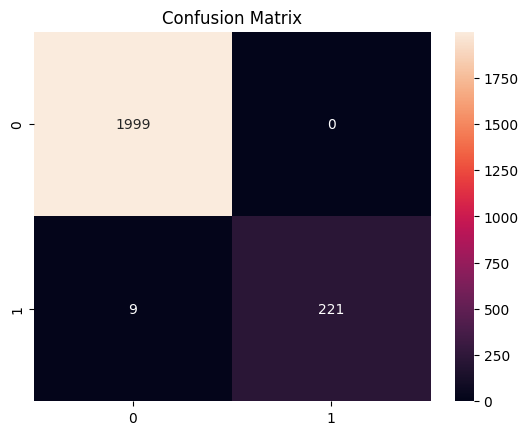

In [30]:
# Shows correct vs incorrect predictions
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [31]:
# Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

# Recall is most important for fraud detection

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1999
           1       1.00      0.96      0.98       230

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229



AUC Score: 0.9999097374774344


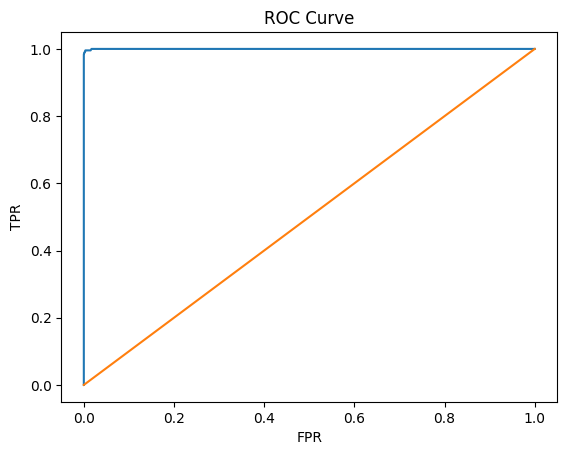

In [49]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability values
y_prob = rf.predict_proba(X_test)[:, 1]

# AUC score          #Higher AUC means better model.”

print("AUC Score:", roc_auc_score(y_test, y_prob))
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # baseline
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

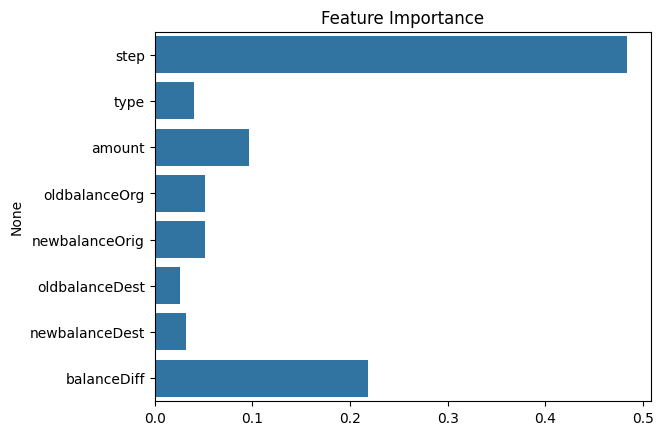

In [47]:
# Feature importance (Random Forest)
importances = rf.feature_importances_
features = X.columns

sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

In [33]:
import pickle
# Save trained model
pickle.dump(rf, open('model.pkl', 'wb'))